In [4]:
import os, sys
repo_root = os.path.abspath('..')
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import get_returns
from src.var_historical import historical_var

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
print("Imports OK")

Imports OK


In [5]:
TICKER = "NVDA"
data = get_returns(TICKER, "2020-01-01")
returns = data['log_return']

# 10-day returns = rolling sum of 10 daily log returns (log returns are additive)
returns_10d = returns.rolling(10).sum().dropna()

print(f"1-day observations: {len(returns)}")
print(f"10-day observations: {len(returns_10d)}")

1-day observations: 1611
10-day observations: 1602


In [6]:
conf = 0.95

# Method A: 1-day VaR scaled by sqrt(10)
var_1d = historical_var(returns, conf, horizon=1)
var_10d_sqrt = var_1d * np.sqrt(10)

# Method B: direct 10-day VaR from overlapping windows
var_10d_direct = -np.percentile(returns_10d, (1-conf)*100)

# Method C: for reference, the 1-day number
print(f"1-day 95% VaR:                  {var_1d:.4f}  ({var_1d:.2%})")
print(f"10-day 95% VaR (sqrt-t rule):   {var_10d_sqrt:.4f}  ({var_10d_sqrt:.2%})")
print(f"10-day 95% VaR (direct/empirical): {var_10d_direct:.4f}  ({var_10d_direct:.2%})")
print(f"\nRatio (direct / sqrt-t): {var_10d_direct/var_10d_sqrt:.3f}")

1-day 95% VaR:                  0.0489  (4.89%)
10-day 95% VaR (sqrt-t rule):   0.1545  (15.45%)
10-day 95% VaR (direct/empirical): 0.1505  (15.05%)

Ratio (direct / sqrt-t): 0.974


Does the square-root-of-time rule hold for NVDA?

The √t rule says: 10-day VaR = 1-day VaR × √10. This assumes returns are
i.i.d. — independent and identically distributed. NVDA violates both:

- Not independent: volatility clusters (Day 1). A big move today raises
  the odds of a big move tomorrow.
- Not identically distributed: the regime in March 2020 was nothing like
  December 2021.

But violating i.i.d. does not guarantee a large error in either direction.
Two forces compete:
- Volatility clustering pushes the ratio ABOVE 1 (multi-day losses compound).
- Positive drift pushes the ratio BELOW 1 (an upward trend cushions losses;
  √t scales volatility only and ignores drift entirely).

The direct-to-√t ratio tells us which force wins for this asset over this window.
√t remains a convenient approximation, not a forecast — a real risk desk would
scale using a model that respects volatility dynamics (GARCH, Week 4).

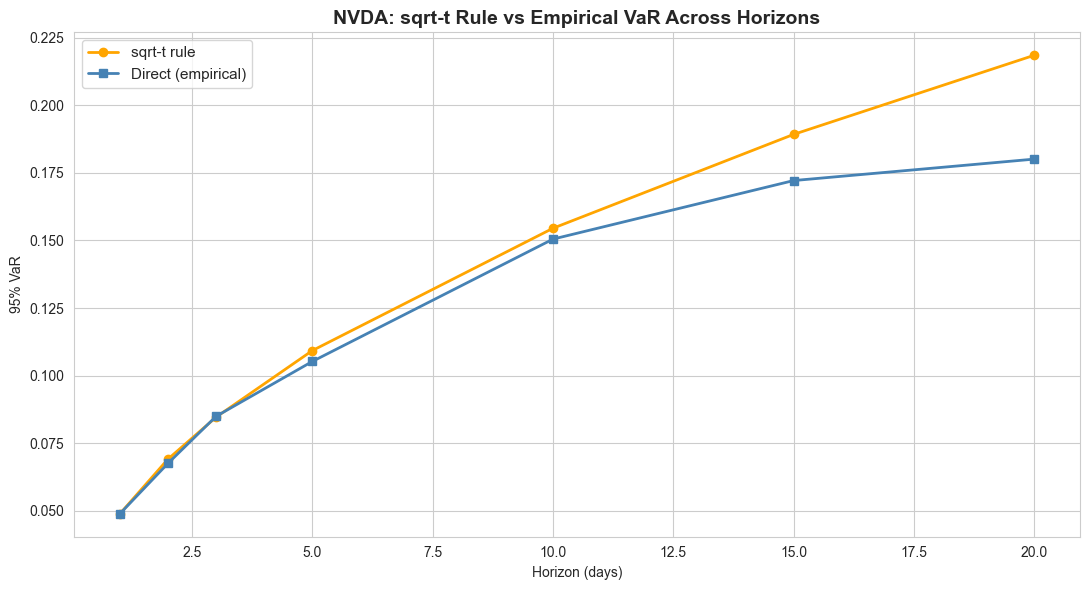

In [7]:
horizons = [1, 2, 3, 5, 10, 15, 20]
sqrt_scaled = [var_1d * np.sqrt(h) for h in horizons]

direct = []
for h in horizons:
    r_h = returns.rolling(h).sum().dropna()
    direct.append(-np.percentile(r_h, (1-conf)*100))

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(horizons, sqrt_scaled, 'o-', color='orange', linewidth=2, label='sqrt-t rule')
ax.plot(horizons, direct, 's-', color='steelblue', linewidth=2, label='Direct (empirical)')
ax.set_title(f'{TICKER}: sqrt-t Rule vs Empirical VaR Across Horizons',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Horizon (days)')
ax.set_ylabel('95% VaR')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/nvda_horizon_scaling.png', dpi=120, bbox_inches='tight')
plt.show()

Key takeaways — horizon scaling

1. Result: ratio = 0.974. The √t rule slightly OVERSTATES NVDA's 10-day VaR
   (15.45% vs 15.05% empirical) — the opposite of the clustering-driven
   understatement often assumed.
2. Why: NVDA's strong positive drift (+0.22%/day, ~+56% annualized) cushions
   multi-day losses. Over a 10-day window, accumulated upward drift offsets
   volatility clustering. √t ignores drift, so it over-scales the loss.
3. The deviation is small (2.6%). For a high-drift asset over a moderate
   horizon, √t is actually a reasonable approximation here — it is not "badly
   broken." Overclaiming would be wrong.
4. Regime-dependent. This full-sample ratio hides regime variation. In a
   negative-drift bear market (e.g. 2022 alone), drift would no longer cushion
   and clustering would likely push the ratio above 1. A regime-split analysis
   is left as future work.
5. Next (Day 5): Monte Carlo VaR under normal AND Student-t innovations to
   model fat tails directly.